In [1]:
import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import scipy.signal as signal

In [2]:
# define path to data and sampling frequency
# adjust the path depending on if you run this script locally or on Kaggle
# DATA_PATH = '/kaggle/input/competitions/ppg-br-exercise-1/mhealth26_ex1.npy'  # for Kaggle
DATA_PATH = './mhealth26_ex1.npy'  # when running locally
FS = 100

In [4]:
# load dictionary from .npy
data = np.load(DATA_PATH, allow_pickle=True).item()

# extract arrays
X_train = data['train_ppg']      
y_train = data['train_labels']   
X_test  = data['test_ppg']       

In [5]:
# example function to plot any signal with time on the x-axis
def plot_signal(signal, title, ylabel, sampling_rate=100):
    x = np.linspace(0, len(signal) / sampling_rate, len(signal))
    t = pd.to_datetime(x, unit='s')

    fig, ax = plt.subplots()
    ax.plot(t, signal)
    ax.set_title(title)
    ax.set_xlabel('Time [min:sec]')
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%M:%S'))
    plt.show()

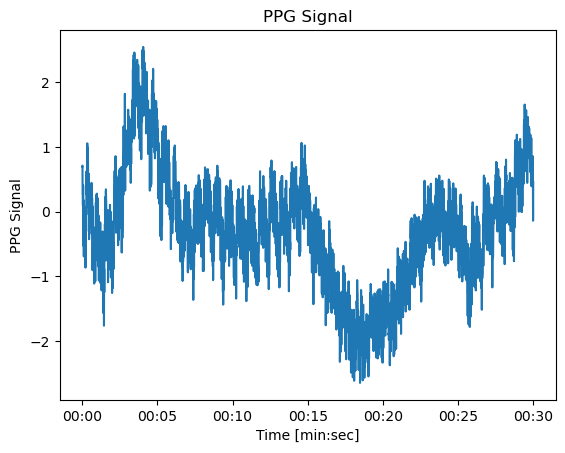

In [8]:
# plot the first 30 seconds of the unfiltered ppg signal of the first window
plot_signal(X_test[19][0:30*FS], 'PPG Signal', 'PPG Signal')

# Pre-Training

## PREPROCESSING

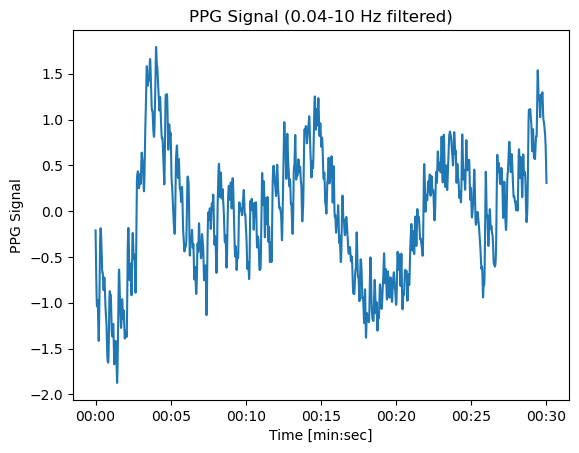

In [ ]:
# PREPROCESSING
# remove baseline drift (<0.03-0.05 Hz) and high-frequency noise (>20 Hz).

def highpass_filter(ppg_window, fs=100, cutoff_hz=0.04, order=2):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff_hz / nyquist
    b, a = signal.butter(order, normal_cutoff, btype='highpass')
    return signal.filtfilt(b, a, ppg_window)

def lowpass_filter(ppg_window, fs=100, cutoff_hz=10.0, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff_hz / nyquist
    b, a = signal.butter(order, normal_cutoff, btype='lowpass')
    return signal.filtfilt(b, a, ppg_window)

def preprocess_window(ppg_window, fs=100, hp_cutoff_hz=0.04, lp_cutoff_hz=10.0):
    x = highpass_filter(ppg_window, fs=fs, cutoff_hz=hp_cutoff_hz, order=2)
    x = lowpass_filter(x, fs=fs, cutoff_hz=lp_cutoff_hz, order=4)
    return x

# Apply per 120-second window for train/test sets
X_train_filt = np.array([preprocess_window(w, fs=FS, hp_cutoff_hz=0.04, lp_cutoff_hz=10.0) for w in X_train])
X_test_filt = np.array([preprocess_window(w, fs=FS, hp_cutoff_hz=0.04, lp_cutoff_hz=10.0) for w in X_test])

# Optional quick check: plot first 30s of filtered test window
plot_signal(X_test_filt[19][0:30*FS], 'PPG Signal (0.04-10 Hz filtered)', 'PPG Signal')


## EXTRACT RESPIRATORY SIGNALS

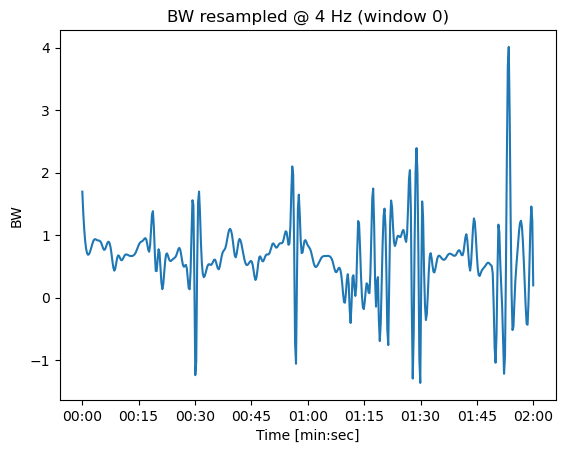

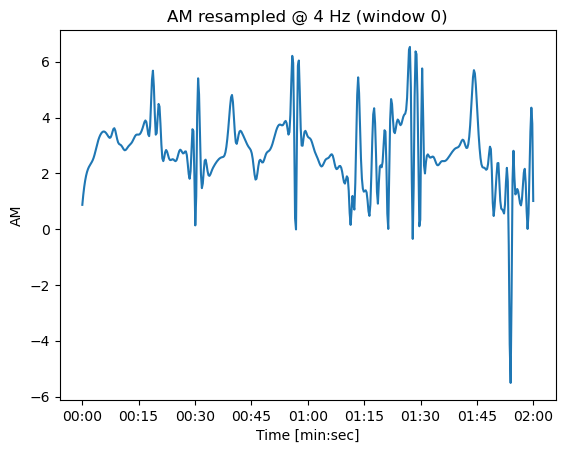

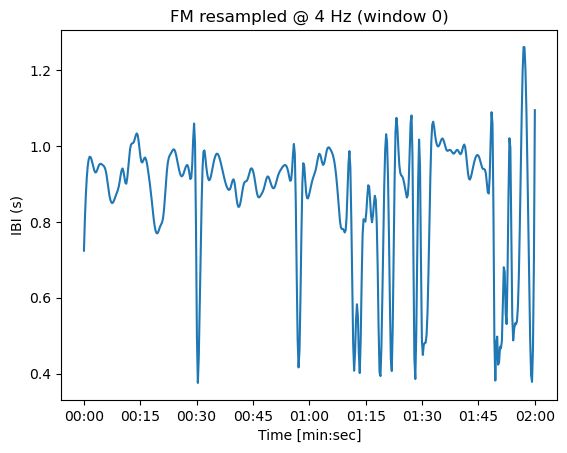

In [ ]:
# RESAMPLE RESPIRATORY SIGNALS

from scipy.interpolate import CubicSpline

RESP_FS = 4  # higher than nyquist frequency (2 x 0.6 Hz)


def resample_resp(ppg_window, extract_fn, fs=100, resp_fs=RESP_FS):
    
    # find peaks and troughs (use maximum heart rate of ~150 bpm)
    peaks, _ = signal.find_peaks(ppg_window, distance=int(0.4 * fs), prominence=0)
    troughs, _ = signal.find_peaks(-ppg_window, distance=int(0.4 * fs))

    beat_times = []
    beat_values = []

    if extract_fn == 'bw':
        for pk in peaks:\

            # pair up peaks and troughs
            preceding = troughs[troughs < pk]
            if len(preceding) == 0:
                continue
            tr = preceding[-1]

            # append to list
            beat_times.append(pk / fs)
            beat_values.append((ppg_window[pk] + ppg_window[tr]) / 2.0)

    elif extract_fn == 'am':
        for pk in peaks:

            # pair up peaks and troughs
            preceding = troughs[troughs < pk]
            if len(preceding) == 0:
                continue
            tr = preceding[-1]

            # append to list
            beat_times.append(pk / fs)
            beat_values.append(ppg_window[pk] - ppg_window[tr])

    elif extract_fn == 'fm':

        # check if there are at least 3 peaks, otherwise peak detection failed
        if len(peaks) < 3:
            duration = len(ppg_window) / fs
            n_out = int(duration * resp_fs)
            return np.zeros(n_out), np.linspace(0, duration, n_out, endpoint=False)

        # calculate inter-beat interval
        ibi = np.diff(peaks).astype(float) / fs

        # append to list
        beat_times = (peaks[1:] / fs).tolist()
        beat_values = ibi.tolist()

    beat_times = np.array(beat_times)
    beat_values = np.array(beat_values)

    # check if there are at least 3 peaks, otherwise peak detection failed
    if len(beat_times) < 3:
        duration = len(ppg_window) / fs
        n_out = int(duration * resp_fs)
        return np.zeros(n_out), np.linspace(0, duration, n_out, endpoint=False)

    # uniform time grid at resp_fs Hz spanning the beat-time range
    duration = len(ppg_window) / fs
    t_uniform = np.linspace(0, duration, int(duration * resp_fs), endpoint=False)

    # cubic spline interpolation (clamp to beat-time range to avoid extrapolation artefacts)
    cs = CubicSpline(beat_times, beat_values, extrapolate=True)
    resampled = cs(t_uniform)

    return resampled, t_uniform

# visualization: resample all three surrogates for one window
demo_idx = 0
ppg_demo = X_test_filt[demo_idx]

bw_resp, t_resp = resample_resp(ppg_demo, 'bw', fs=FS)
am_resp, _      = resample_resp(ppg_demo, 'am', fs=FS)
fm_resp, _      = resample_resp(ppg_demo, 'fm', fs=FS)

plot_signal(bw_resp, f'BW resampled @ {RESP_FS} Hz (window {demo_idx})', 'BW', sampling_rate=RESP_FS)
plot_signal(am_resp, f'AM resampled @ {RESP_FS} Hz (window {demo_idx})', 'AM', sampling_rate=RESP_FS)
plot_signal(fm_resp, f'FM resampled @ {RESP_FS} Hz (window {demo_idx})', 'IBI (s)', sampling_rate=RESP_FS)

# ML Modeling and Training

In [ ]:
# create input for ML

RESP_FS = 4

def create_ml_input(X_windows, fs=100, resp_fs=RESP_FS):
    X_out = []

    for ppg_window in X_windows:
        bw, _ = resample_resp(ppg_window, 'bw', fs=fs, resp_fs=resp_fs)
        am, _ = resample_resp(ppg_window, 'am', fs=fs, resp_fs=resp_fs)
        fm, _ = resample_resp(ppg_window, 'fm', fs=fs, resp_fs=resp_fs)

        sample = np.vstack([bw, am, fm])   # shape: (3, 480)
        X_out.append(sample)

    return np.array(X_out)

X_train_ml = create_ml_input(X_train_filt, fs=FS, resp_fs=RESP_FS)
X_test_ml  = create_ml_input(X_test_filt, fs=FS, resp_fs=RESP_FS)

(643, 3, 480)
(645, 3, 480)


In [17]:
# normalize features

def normalize_per_channel(X_train, X_test):
    # X shape: (n_samples, 3, 480)
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True) + 1e-8

    X_train_norm = (X_train - mean) / std
    X_test_norm  = (X_test - mean) / std

    return X_train_norm, X_test_norm, mean, std

X_train_ml, X_test_ml, mean_ml, std_ml = normalize_per_channel(X_train_ml, X_test_ml)

In [39]:
# hyperparameter tuning for random forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV

X_train_flat = X_train_ml.reshape(X_train_ml.shape[0], -1)
X_test_flat  = X_test_ml.reshape(X_test_ml.shape[0], -1)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_flat, y_train, test_size=0.2, random_state=42
)

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 0.5]
}

rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

grid = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_tr, y_tr)

print("Best CV MAE:", -grid.best_score_)
print("Best params:", grid.best_params_)

rf = grid.best_estimator_

val_pred = rf.predict(X_val)
mae = mean_absolute_error(y_val, val_pred)
print("Validation MAE:", mae)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best CV MAE: 4.098153215665137
Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Validation MAE: 4.109111088693217


In [40]:
# final model training

rf = RandomForestRegressor(
    **grid.best_params_,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_flat, y_train)

print("Final RF trained on full training set.")
print("Best params used:", grid.best_params_)

Final RF trained on full training set.
Best params used: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}


## Submission

In [ ]:
# function to predict BR for a single 120-second window
def predict_br(ppg_window):

    ppg_window = preprocess_window(
        ppg_window,
        fs=FS,
        hp_cutoff_hz=0.04,
        lp_cutoff_hz=10.0
    )

    bw, _ = resample_resp(ppg_window, 'bw', fs=FS, resp_fs=RESP_FS)
    am, _ = resample_resp(ppg_window, 'am', fs=FS, resp_fs=RESP_FS)
    fm, _ = resample_resp(ppg_window, 'fm', fs=FS, resp_fs=RESP_FS)

    x = np.vstack([bw, am, fm])
    x = x.reshape(1, -1)

    pred = rf.predict(x)[0]

    # match label / assignment format
    pred = np.clip(pred, 8, 40)
    pred = np.round(pred * 2) / 2

    return [float(pred)]

In [46]:
# function to print the mean absolute error between your predicted BR and the BR labels
# with this function, you can evaluate the resulting score that you would obtain on the test set
# with your predicted BR values
def print_score(pred_br, label_br):
    err = np.abs(np.asarray(pred_br) - np.asarray(label_br))
    print("Mean absolute error: {:4.3f}".format(np.mean(err)))

In [48]:
# create the submission file called "submission.csv"
# download the file and submit it to the kaggle competition to obtain a score on the leaderboard
idxs = []
preds = []

# loop through all test windows
# important: loop through the windows as below, add the predictions in the same order and keep the naming of window{i}_{j}
# we will only evaluate your predictions for the test set
for i, ppg in enumerate(X_test):
    # index needed for kaggle submission file
    idxs.extend([i])
    # your predictions based on the above function
    preds.extend(predict_br(ppg))

# on the right side in tab "Output", you should now see a file called "submission.csv" after pressing the refresh button
# download the file and submit it to this competition to obtain a score on the leaderboard
df = pd.DataFrame({'Id': idxs, 'Predicted': preds})
# df.to_csv('/kaggle/working/submission.csv', index=False)  # for Kaggle
df.to_csv('./submission.csv', index=False)  # when running locally

In [44]:
# example on how to use the print_score function with randomly generated BR values as the predictions and labels
pred_br_random = list(np.random.randint(8, 40, len(preds)))
label_br_random = list(np.random.randint(8, 40, len(preds)))
print_score(pred_br_random, label_br_random)

Mean absolute error: 10.950


In [51]:
val_pred = rf.predict(X_val)

print_score(val_pred, y_val)

Mean absolute error: 1.533
